[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


CUSTOMER REVIEW CLEANING SYSTEM

Public dataset could not be loaded.
Using sample customer review dataset instead.

Dataset shape:
(15, 3)

Column names:
['Score', 'Summary', 'Text']

First 5 records:
   Score            Summary                                               Text
0      5  Excellent product  I absolutely LOVE this product!!! The quality ...
1      4       Good quality  Very good product and fast delivery. I am happ...
2      5      Amazing taste  This product tastes great and I would definite...
3      2      Not satisfied  The product was okay but the quality was not v...
4      1           Very bad      Terrible product!!! I did not like it at all.

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Score    15 non-null     int64 
 1   Summary  15 non-null     object
 2   Text     15 non-null     object
dtypes: int64(1),

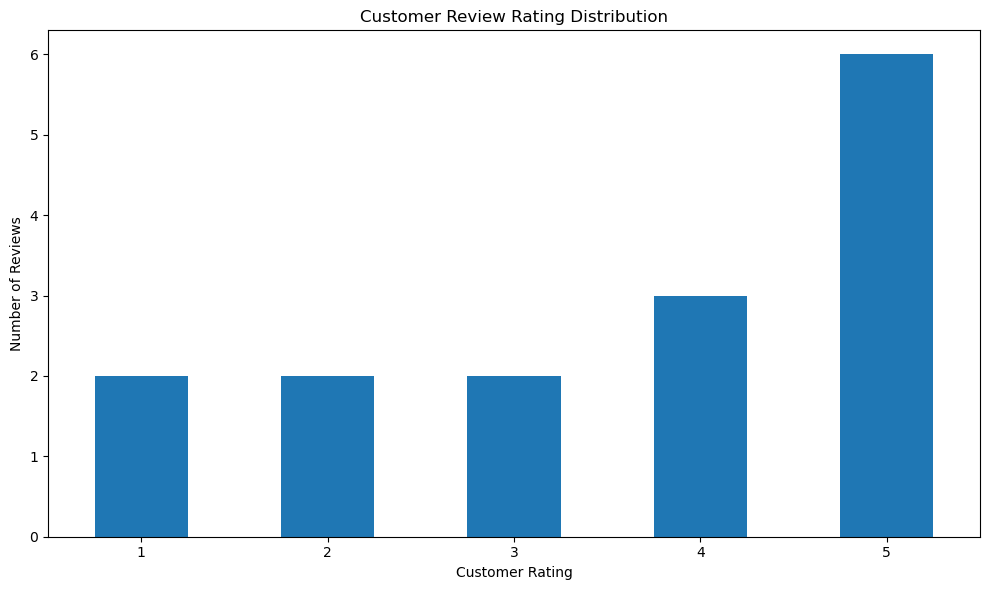

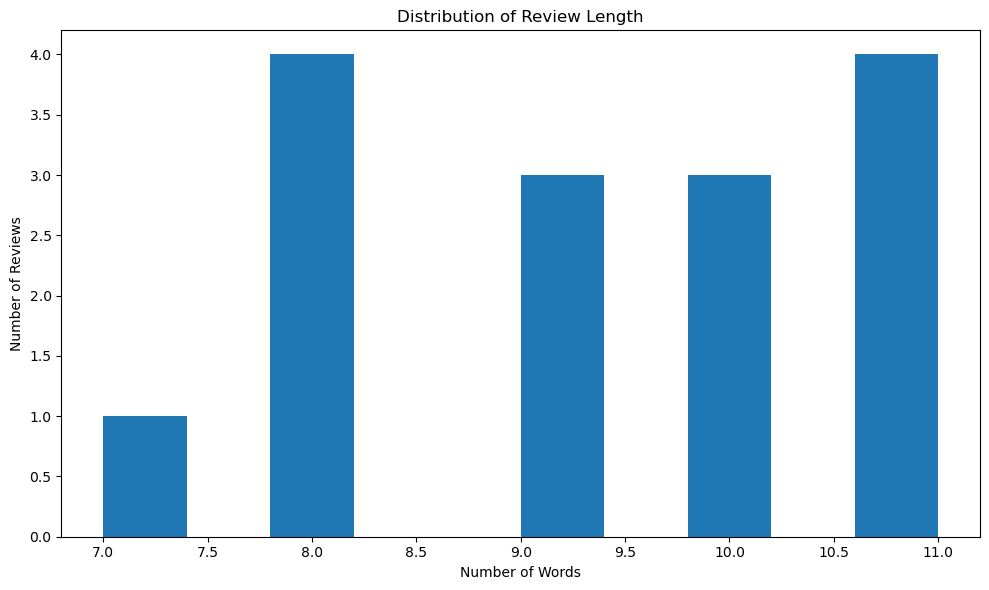


TOP 20 MOST COMMON WORDS
product              11
quality              8
good                 6
amazing              3
loved                3
absolutely           2
fast                 2
delivery             2
definitely           2
buy                  2
okay                 2
excellent            2
love                 1
happy                1
taste                1
great                1
would                1
terrible             1
like                 1
highly               1


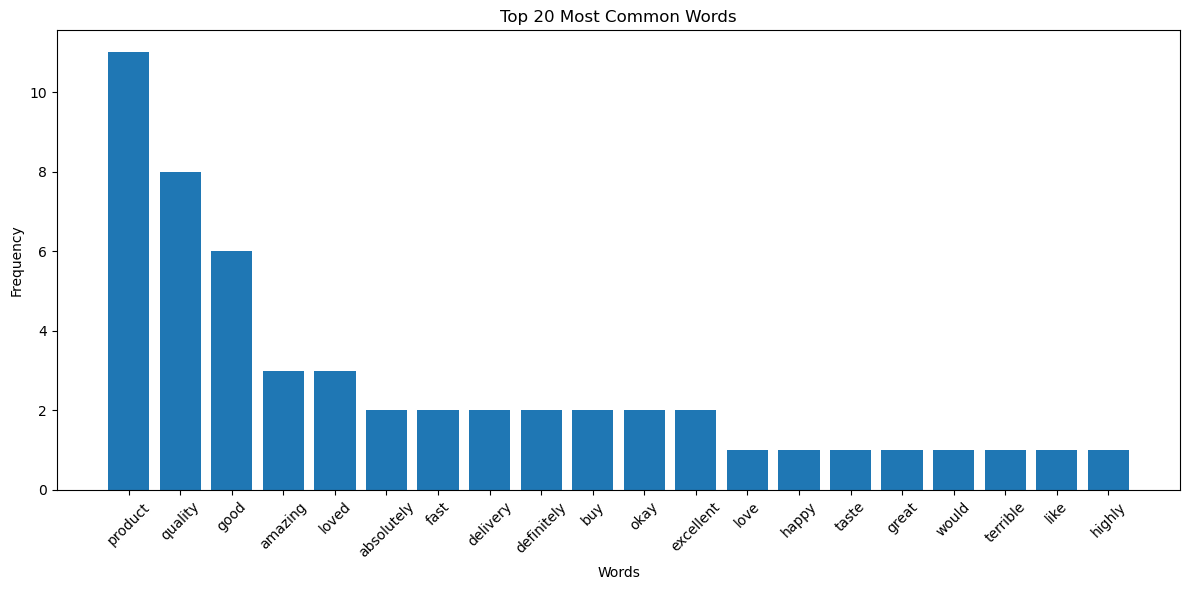


CLEANED DATASET SAVED

File name: cleaned_customer_reviews.csv

CUSTOMER REVIEW CLEANER

Original Review:

OMG!!! I absolutely LOVE this product!!! 😍😍
The quality is AMAZING and the delivery was very fast!!!
Visit https://example.com for more information.
I would definitely buy this product again!!!


Cleaned Review:
omg absolutely love product quality amazing delivery fast visit information would definitely buy product

Original word count: 29
Cleaned word count: 14

INTERACTIVE CUSTOMER REVIEW CLEANER

Enter a customer review.
Type 'exit' to stop.


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("=" * 60)
print("CUSTOMER REVIEW CLEANING SYSTEM")
print("=" * 60)

url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/amazon-fine-food-reviews.csv"

try:

    df = pd.read_csv(
        url,
        nrows=10000
    )

    print("\nPublic dataset loaded successfully!")

except Exception as e:

    print("\nPublic dataset could not be loaded.")
    print("Using sample customer review dataset instead.")

    data = {
        "Score": [
            5, 4, 5, 2, 1,
            5, 4, 3, 1, 5,
            4, 5, 2, 3, 5
        ],

        "Summary": [
            "Excellent product",
            "Good quality",
            "Amazing taste",
            "Not satisfied",
            "Very bad",
            "Highly recommended",
            "Good product",
            "Average product",
            "Poor quality",
            "Excellent",
            "Worth buying",
            "Fantastic product",
            "Not good",
            "It is okay",
            "Loved it"
        ],

        "Text": [
            "I absolutely LOVE this product!!! The quality is AMAZING.",
            "Very good product and fast delivery. I am happy with it.",
            "This product tastes great and I would definitely buy it again!",
            "The product was okay but the quality was not very good.",
            "Terrible product!!! I did not like it at all.",
            "Excellent quality and very fast delivery. Highly recommended!",
            "Good product. The price is reasonable and quality is good.",
            "The product is average. Nothing special about it.",
            "Very poor quality. I will never buy this again.",
            "Amazing product!!! I loved it and will definitely recommend it.",
            "Worth buying. Good quality and excellent service.",
            "Fantastic product 😍😍 I absolutely loved the quality!",
            "Not good. The product arrived late and the package was damaged.",
            "It is okay. The quality could be better.",
            "I loved this product!!! It was amazing and very useful."
        ]
    }

    df = pd.DataFrame(data)

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 records:")
print(df.head())

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

df = df.dropna(
    subset=["Text"]
)

print("\nShape after removing missing reviews:")
print(df.shape)

duplicate_count = df.duplicated(
    subset=["Text"]
).sum()

print("\nDuplicate reviews:")
print(duplicate_count)

df = df.drop_duplicates(
    subset=["Text"]
)

print("\nShape after removing duplicates:")
print(df.shape)

stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

def clean_review(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    text = re.sub(
        r"\d+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    words = word_tokenize(
        text
    )

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    words = [
        word
        for word in words
        if len(word) > 2
    ]

    return " ".join(words)

print("\n" + "=" * 60)
print("ORIGINAL REVIEW")
print("=" * 60)

print(
    df["Text"].iloc[0]
)

print("\nCleaning reviews...")

df["Cleaned_Text"] = df[
    "Text"
].apply(
    clean_review
)

print(
    "Cleaning completed successfully!"
)

print("\n" + "=" * 60)
print("CLEANED REVIEW")
print("=" * 60)

print(
    df["Cleaned_Text"].iloc[0]
)

print("\n" + "=" * 60)
print("ORIGINAL VS CLEANED REVIEWS")
print("=" * 60)

for i in range(
    min(5, len(df))
):

    print(
        "\n----------------------------------------"
    )

    print("\nOriginal Review:")

    print(
        df["Text"].iloc[i]
    )

    print("\nCleaned Review:")

    print(
        df["Cleaned_Text"].iloc[i]
    )

df["Original_Word_Count"] = df[
    "Text"
].apply(
    lambda x: len(
        str(x).split()
    )
)

df["Cleaned_Word_Count"] = df[
    "Cleaned_Text"
].apply(
    lambda x: len(
        str(x).split()
    )
)

print("\n" + "=" * 60)
print("WORD COUNT COMPARISON")
print("=" * 60)

print(
    df[
        [
            "Original_Word_Count",
            "Cleaned_Word_Count"
        ]
    ].head(10)
)

total_reviews = len(df)

total_original_words = df[
    "Original_Word_Count"
].sum()

total_cleaned_words = df[
    "Cleaned_Word_Count"
].sum()

words_removed = (
    total_original_words
    - total_cleaned_words
)

print("\n" + "=" * 60)
print("CLEANING STATISTICS")
print("=" * 60)

print(
    "\nTotal reviews:",
    total_reviews
)

print(
    "\nOriginal total words:",
    total_original_words
)

print(
    "\nCleaned total words:",
    total_cleaned_words
)

print(
    "\nWords removed:",
    words_removed
)

if total_original_words > 0:

    reduction_percentage = (
        words_removed /
        total_original_words
    ) * 100

else:

    reduction_percentage = 0

print(
    "\nText reduction:",
    round(
        reduction_percentage,
        2
    ),
    "%"
)

print("\n" + "=" * 60)
print("CUSTOMER RATING DISTRIBUTION")
print("=" * 60)

print(
    df["Score"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(10, 6)
)

df[
    "Score"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel(
    "Customer Rating"
)

plt.ylabel(
    "Number of Reviews"
)

plt.title(
    "Customer Review Rating Distribution"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df["Original_Word_Count"],
    bins=10
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Number of Reviews"
)

plt.title(
    "Distribution of Review Length"
)

plt.tight_layout()

plt.show()

all_words = []

for review in df[
    "Cleaned_Text"
]:

    words = review.split()

    all_words.extend(
        words
    )

word_counts = Counter(
    all_words
)

top_words = word_counts.most_common(
    20
)

print("\n" + "=" * 60)
print("TOP 20 MOST COMMON WORDS")
print("=" * 60)

for word, count in top_words:

    print(
        f"{word:<20} {count}"
    )

top_words_df = pd.DataFrame(
    top_words,
    columns=[
        "Word",
        "Frequency"
    ]
)

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xlabel(
    "Words"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Top 20 Most Common Words"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

output_file = (
    "cleaned_customer_reviews.csv"
)

df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 60)
print("CLEANED DATASET SAVED")
print("=" * 60)

print(
    "\nFile name:",
    output_file
)

def clean_new_review(review):

    print(
        "\n" + "=" * 60
    )

    print(
        "CUSTOMER REVIEW CLEANER"
    )

    print(
        "=" * 60
    )

    print(
        "\nOriginal Review:"
    )

    print(
        review
    )

    cleaned = clean_review(
        review
    )

    print(
        "\nCleaned Review:"
    )

    print(
        cleaned
    )

    print(
        "\nOriginal word count:",
        len(review.split())
    )

    print(
        "Cleaned word count:",
        len(cleaned.split())
    )

    print(
        "=" * 60
    )

    return cleaned

new_review = """
OMG!!! I absolutely LOVE this product!!! 😍😍
The quality is AMAZING and the delivery was very fast!!!
Visit https://example.com for more information.
I would definitely buy this product again!!!
"""

clean_new_review(
    new_review
)

print(
    "\n" + "=" * 60
)

print(
    "INTERACTIVE CUSTOMER REVIEW CLEANER"
)

print(
    "=" * 60
)

print(
    "\nEnter a customer review."
)

print(
    "Type 'exit' to stop."
)

while True:

    user_review = input(
        "\nEnter review: "
    )

    if user_review.lower() == "exit":

        print(
            "\nProgram stopped."
        )

        break

    if user_review.strip() == "":

        print(
            "Please enter a review."
        )

        continue

    clean_new_review(
        user_review
    )

print(
    "\n" + "=" * 60
)

print(
    "CUSTOMER REVIEW CLEANING SYSTEM COMPLETED"
)

print(
    "=" * 60
)